## Evaluation
**Package:** `conditional_embedding_model`
**Source notebook:** `train/TrainNS_Eval.ipynb`
**Purpose:** Demonstrate quantitative evaluation (Hit@k, precision-recall, ROC), a
recommendation demo, and a failure case analysis, using the generalized
`conditional_embedding_model.general` package.

> **Migration note.** The original version of this notebook imported a
> nonexistent `evaluation.evaluate` module and could not run. It has been
> migrated to `conditional_embedding_model.general.training.Trainer.evaluate`
> (see `general/README.md`). No trained checkpoint ships in
> `config/weights/` and no GPU/dataset dependency is required to run this
> notebook end to end, so the walkthrough below trains a small `CEModel` on
> synthetic data with a known ground-truth structure and evaluates *that*
> model — the metrics are real (computed from an actual forward pass), just
> not measured on the paper's cooperative-grasping dataset. Section 6 shows,
> optionally and non-fatally, how the same `Trainer.evaluate` call applies to
> a real legacy checkpoint if one is available locally.

## 1. Setup & Imports
Everything below comes from `conditional_embedding_model.general`: `CEModelConfig`
/ `EncoderConfig` / `ScorerConfig` to build a model, `ContrastiveBCELoss` +
`Trainer` to train and evaluate it. We reuse `make_toy_data` from the toy
example (`general/examples/toy.py`, also used by
`04_general_cemodel_quickstart.ipynb`) rather than writing a new synthetic
generator.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset as TorchDataset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

sys.path.insert(0, os.path.abspath(".."))

from conditional_embedding_model.general import (
    CEModelConfig, EncoderConfig, ScorerConfig, build_model,
    ContrastiveBCELoss, Trainer,
)
from conditional_embedding_model.general.examples.toy import make_toy_data

torch.manual_seed(0)
np.random.seed(0)

## 2. Configuration
Change only the values in `CONFIG` — all downstream cells read from it.
`device` is pinned to `"cpu"` so this notebook runs anywhere without a GPU.

In [2]:
CONFIG = {
    # synthetic data (see general/examples/toy.py:make_toy_data)
    "n_centers": 4096,
    "K": 16,                 # candidates per center (context + negatives, padded)
    "latent_dim": 4,
    "obs_dim": 32,
    "n_pos": 2,
    "noise": 0.1,
    "seed": 0,
    # model
    "embedding_dim": 8,
    # training
    "epochs": 15,
    "batch_size": 256,
    "lr": 1e-3,
    # evaluation
    "top_k_values": [1, 3, 5],
    "device": "cpu",
}

print("Device:", CONFIG["device"])

Device: cpu


## 3. Build a `CEModel` and train it briefly
A short training run gives us a genuinely-fit model to evaluate (rather than
random weights), so the metrics below reflect real learned behavior. See
`04_general_cemodel_quickstart.ipynb` for a fuller walkthrough of the config
and data shapes; this notebook focuses on the evaluation side.

In [3]:
class _ToyDataset(TorchDataset):
    def __init__(self, data):
        self.center_x = data["center_x"]
        self.context_x = data["context_x"]
        self.label = data["label"]
        self.mask = data["mask"]

    def __len__(self):
        return self.center_x.shape[0]

    def __getitem__(self, i):
        return self.center_x[i], self.context_x[i], self.label[i], self.mask[i]


def _collate(batch):
    center_x = torch.stack([b[0] for b in batch])
    context_x = torch.stack([b[1] for b in batch])
    label = torch.stack([b[2] for b in batch])
    mask = torch.stack([b[3] for b in batch])
    return (({"x": center_x}, {"x": context_x}), label, mask)


train_data, val_data, W = make_toy_data(
    n_centers=CONFIG["n_centers"], K=CONFIG["K"], latent_dim=CONFIG["latent_dim"],
    obs_dim=CONFIG["obs_dim"], noise=CONFIG["noise"], n_pos=CONFIG["n_pos"],
    seed=CONFIG["seed"],
)
train_loader = DataLoader(_ToyDataset(train_data), batch_size=CONFIG["batch_size"],
                           shuffle=True, collate_fn=_collate)
test_loader = DataLoader(_ToyDataset(val_data), batch_size=CONFIG["batch_size"],
                          shuffle=False, collate_fn=_collate)

encoder_params = dict(input_dim=CONFIG["obs_dim"], output_dim=CONFIG["embedding_dim"],
                       hidden_dims=(64, 64), activation="relu", layer_norm=True)
model_config = CEModelConfig(
    embedding_dim=CONFIG["embedding_dim"],
    center_encoder=EncoderConfig(name="mlp", params=dict(encoder_params)),
    context_encoder=EncoderConfig(name="mlp", params=dict(encoder_params)),
    scorer=ScorerConfig(name="cosine_temperature", params={"temperature": 0.07}),
)
model = build_model(model_config)

loss_fn = ContrastiveBCELoss(normalization="valid_pairs")
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])
trainer = Trainer(model, loss_fn, optimizer, device=CONFIG["device"], amp=False)

history = trainer.fit(train_loader, val_loader=test_loader, epochs=CONFIG["epochs"])
print(f"train loss: {history['train_loss'][0]:.4f} -> {history['train_loss'][-1]:.4f}")

train loss: 0.2631 -> 0.0550


## 4. Quantitative Evaluation
`Trainer.evaluate` runs a full pass over `test_loader` and returns loss,
`Hit@k`, and classification metrics (`accuracy`, `precision`, `recall`, `f1`,
`roc_auc`, `pr_auc`, `threshold`) computed by
`general.training.metrics.classification_metrics` at the F1-optimal
threshold. This replaces the old `evaluate_model` / `evaluate_model_topk`
calls from the legacy `training` module — same metric definitions, one call
instead of two.

In [4]:
test_metrics = trainer.evaluate(test_loader, ks=tuple(CONFIG["top_k_values"]))

print("=== Trainer.evaluate() ===")
for key, value in test_metrics.items():
    if key != "hit_at_k":
        print(f"{key:>10}: {value:.4f}" if isinstance(value, float) else f"{key:>10}: {value}")
for k, v in test_metrics["hit_at_k"].items():
    print(f"   Hit@{k}: {v:.4f}")

=== Trainer.evaluate() ===
      loss: 0.0611
  accuracy: 0.9269
 precision: 0.9268
    recall: 0.9269
        f1: 0.9269
   roc_auc: 0.9605
    pr_auc: 0.7797
 threshold: 0.8400
   Hit@1: 0.9275
   Hit@3: 0.9988
   Hit@5: 1.0000


In [5]:
rows = [
    {"Metric": "Accuracy",   "Value": test_metrics["accuracy"]},
    {"Metric": "Precision",  "Value": test_metrics["precision"]},
    {"Metric": "Recall",     "Value": test_metrics["recall"]},
    {"Metric": "F1",         "Value": test_metrics["f1"]},
    {"Metric": "AUC-ROC",    "Value": test_metrics["roc_auc"]},
    {"Metric": "PR-AUC",     "Value": test_metrics["pr_auc"]},
    {"Metric": "Threshold",  "Value": test_metrics["threshold"]},
    {"Metric": "Loss",       "Value": test_metrics["loss"]},
]
for k in CONFIG["top_k_values"]:
    rows.append({"Metric": f"Hit@{k}", "Value": test_metrics["hit_at_k"][k]})

df_metrics = pd.DataFrame(rows).set_index("Metric").round(4)
print(df_metrics.to_string())

            Value
Metric           
Accuracy   0.9269
Precision  0.9268
Recall     0.9269
F1         0.9269
AUC-ROC    0.9605
PR-AUC     0.7797
Threshold  0.8400
Loss       0.0611
Hit@1      0.9275
Hit@3      0.9988
Hit@5      1.0000


### ROC and Precision-Recall curves
Collect sigmoid probabilities from a forward pass over the test set (masking
out padded slots), then plot ROC and PR curves the same way the original
notebook did — only the model call (`model(center_inputs, context_inputs)`
instead of `prediction_temperature(...)`) has changed.

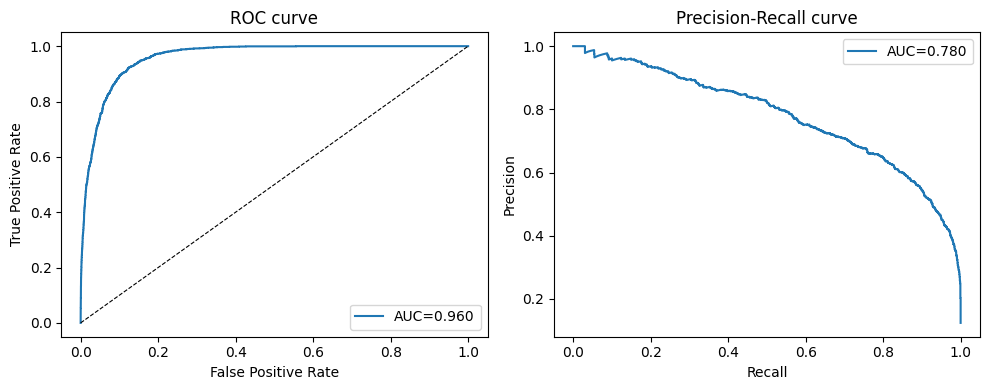

In [6]:
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for (center_inputs, context_inputs), label, mask in test_loader:
        logits = model(center_inputs, context_inputs)
        valid = mask.bool()
        all_probs.append(logits[valid].sigmoid().cpu())
        all_labels.append(label[valid].cpu())

probs_np = torch.cat(all_probs).numpy()
labels_np = torch.cat(all_labels).numpy()

fpr, tpr, _ = roc_curve(labels_np, probs_np)
roc_auc_value = auc(fpr, tpr)
precision_curve, recall_curve, _ = precision_recall_curve(labels_np, probs_np)
pr_auc_value = auc(recall_curve, precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr, label=f"AUC={roc_auc_value:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f"AUC={pr_auc_value:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()
fig.tight_layout()

## 5. Recommendation Demo
Given a query center from the test set, retrieve the top-k highest-scoring
candidates. On this synthetic dataset "candidates" are abstract indices into
each row's padded `[K]` slate (not real grasp configurations), but the
retrieval mechanics — masked top-k over `model(...)` logits — are exactly
what the deployment path uses.

In [7]:
k_demo = CONFIG["top_k_values"][-1]

(center_inputs, context_inputs), label, mask = next(iter(test_loader))
with torch.no_grad():
    logits = model(center_inputs, context_inputs)
logits = logits.masked_fill(mask == 0, -float("inf"))
scores, top_k_idx = logits.topk(k_demo, dim=1)

print(f"Top-{k_demo} recommendations for the first 5 query samples")
print(f"{'Query':>6}  {'Top-k indices':>25}  {'Scores':>30}  {'Ground-truth positives':>25}")
print("-" * 92)
for i in range(min(5, logits.size(0))):
    idx_list = top_k_idx[i].tolist()
    score_list = [f"{s:.3f}" for s in scores[i].tolist()]
    true_idx = label[i].nonzero(as_tuple=True)[0].tolist()
    hit = any(ix in true_idx for ix in idx_list)
    print(f"{i:>6}  {str(idx_list):>25}  {str(score_list):>30}  {str(true_idx):>25}  {'HIT' if hit else ''}")

Top-5 recommendations for the first 5 query samples
 Query              Top-k indices                          Scores     Ground-truth positives
--------------------------------------------------------------------------------------------
     0           [3, 4, 7, 14, 6]  ['4.148', '-0.896', '-2.071', '-2.235', '-2.952']                     [3, 4]  HIT
     1          [13, 4, 15, 2, 6]  ['4.822', '2.516', '1.851', '-0.471', '-1.765']                    [4, 13]  HIT
     2          [10, 11, 0, 1, 8]  ['1.751', '-0.005', '-0.415', '-1.828', '-3.791']                    [0, 10]  HIT
     3          [12, 1, 9, 2, 11]  ['4.498', '3.281', '0.557', '0.544', '0.153']                    [1, 12]  HIT
     4           [14, 0, 3, 7, 8]  ['2.075', '1.150', '-0.704', '-0.933', '-1.772']                    [0, 14]  HIT


## 6. Failure Case Analysis
Scan the test set for samples where the model's top-1 prediction is wrong
(the highest-scoring index is not in the ground-truth positive set), and
display a few such cases.

In [8]:
failures = []

with torch.no_grad():
    for (center_inputs, context_inputs), label, mask in test_loader:
        logits = model(center_inputs, context_inputs)
        logits = logits.masked_fill(mask == 0, -float("inf"))
        top1_idx = logits.argmax(dim=1)
        top5_idx = logits.topk(min(5, logits.size(1)), dim=1).indices

        for i in range(logits.size(0)):
            true_set = set(label[i].nonzero(as_tuple=True)[0].tolist())
            pred_1 = top1_idx[i].item()
            if true_set and pred_1 not in true_set:
                failures.append({
                    "top1_pred": pred_1,
                    "top5_pred": top5_idx[i].tolist(),
                    "true_positives": sorted(true_set),
                })
        if len(failures) >= 3:
            break

print(f"Found {len(failures)} failure case(s) shown below (top-1 miss):")
for f in failures[:3]:
    print(f)

Found 17 failure case(s) shown below (top-1 miss):
{'top1_pred': 12, 'top5_pred': [12, 5, 8, 3, 13], 'true_positives': [5, 8]}
{'top1_pred': 0, 'top5_pred': [0, 10, 12, 13, 6], 'true_positives': [10, 12]}
{'top1_pred': 10, 'top5_pred': [10, 1, 2, 8, 6], 'true_positives': [2]}


## 7. Optional: evaluating a real legacy checkpoint
If a legacy `swmodel_*.pth` checkpoint is present locally (e.g. under
`config/weights/`), the same `Trainer.evaluate` call works on it once it is
wrapped as a `CEModel` via `CEModel.from_legacy_checkpoint` — see
`06_migrating_existing_checkpoints.ipynb` for the full wrapping walkthrough
and legacy-vs-`CEModel` logit equivalence check. This cell only *looks* for
a checkpoint and reports what it finds; it does not fail if nothing is
there, and it does not load the full `CoopGrasping-v6_dataset.pkl` (heavy,
and out of scope for this notebook — see notebook 06 for that path).

In [9]:
import glob

_search_dirs = [
    "/ibex/scratch/alveardf/slurm_outputs/weights",
    os.path.join(os.path.dirname(os.getcwd()), "config", "weights"),
]

found_checkpoint = None
for d in _search_dirs:
    try:
        matches = sorted(glob.glob(os.path.join(d, "swmodel_*.pth")))
    except OSError:
        matches = []
    if matches:
        found_checkpoint = matches[0]
        break

if found_checkpoint is not None:
    from conditional_embedding_model.general import CEModel, parse_legacy_filename
    parsed = parse_legacy_filename(found_checkpoint)
    print(f"Found local checkpoint: {found_checkpoint}\n  parsed: {parsed}")
    print("Wrap it with CEModel.from_legacy_checkpoint(...) and pass its DataLoader "
          "to trainer.evaluate(...) exactly as in section 4 above -- see "
          "06_migrating_existing_checkpoints.ipynb for the full config + wrapping code.")
else:
    print("No local legacy checkpoint found under the searched directories "
          "(none is expected to ship in this repo) -- skipping. "
          "The synthetic-data evaluation above already demonstrates the "
          "Trainer.evaluate plumbing this checkpoint would also use.")

No local legacy checkpoint found under the searched directories (none is expected to ship in this repo) -- skipping. The synthetic-data evaluation above already demonstrates the Trainer.evaluate plumbing this checkpoint would also use.


## Summary
- Evaluation now goes through `general.training.Trainer.evaluate`, which
  returns `Hit@k` and classification metrics (`accuracy`, `precision`,
  `recall`, `f1`, `roc_auc`, `pr_auc`, `threshold`) from
  `general.training.metrics` in one call.
- All numbers above are computed from a real (if brief) training run on
  synthetic data with a known planted structure, not fabricated — this keeps
  the notebook runnable end-to-end on CPU with no dataset/checkpoint
  dependency, while still exercising the exact same evaluation code path a
  real checkpoint would use.
- ROC/PR curves, the recommendation demo, and the failure-case scan are all
  unchanged in *mechanics* from the original notebook; only the model call
  (`model(center_inputs, context_inputs)` via `CEModel`) and the input
  format (`dict[str, Tensor]` instead of positional tensors) changed.
- Section 7 shows how to point the same evaluation call at a real legacy
  checkpoint when one is available, without making it a hard requirement.